## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [85]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [86]:
#Проверим на наличие пропущенных значений
data.isna().sum()

Species                 0
Island                  0
Clutch Completion       0
Date Egg                0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Sex                    10
Delta 15 N (o/oo)      14
Delta 13 C (o/oo)      13
dtype: int64

In [87]:
#Удаляем пропушенные значения, так как нас попросили)
data = data.dropna()

In [88]:
#Пропущенные значения удалились
data.isna().sum()

Species                0
Island                 0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64

In [89]:
#Теперь ищем категориальные признаки
data.dtypes

Species                    str
Island                     str
Clutch Completion          str
Date Egg                 int64
Culmen Length (mm)     float64
Culmen Depth (mm)      float64
Flipper Length (mm)    float64
Body Mass (g)          float64
Sex                        str
Delta 15 N (o/oo)      float64
Delta 13 C (o/oo)      float64
dtype: object

In [90]:
#Посмотрим, какие значения принимает категориальные признаки в целом
print(data.apply(lambda col: col.unique() if col.dtype == 'object' else 0))

Species                0
Island                 0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64


Можно заметить, что категориальные признаки тут либо номинальные, либо бинарные. Значит, отражать порядок не имеет смысла и **LabelEncoder** не требуется, достаточно обычного **One-Hot-кодирования**

In [91]:
from sklearn.preprocessing import OrdinalEncoder


data['Species_enc'] = OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']]).fit_transform(data[['Species']])
data = pd.get_dummies(data.drop('Species', axis=1), drop_first=True, dtype=int)

Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [92]:
data.head()

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Species_enc,Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE
0,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,0.0,1,0,1,0,1
1,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,0.0,1,0,1,1,0
2,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,1.0,0,0,1,1,0
3,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,0.0,1,0,1,1,0
4,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,1.0,0,0,1,1,0


In [93]:
#Наконец, разделим датафрейм на X и y
y = data['Species_enc']
X = data.drop('Species_enc', axis=1)

In [94]:
y.value_counts()

Species_enc
2.0    139
1.0    119
0.0     67
Name: count, dtype: int64

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [95]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

**Stratify** нужен, чтобы при деление выборки на тестовую и обучающую сохранилась пропорция классов целевой переменной

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


cols = ['Flipper Length (mm)', 'Body Mass (g)']
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_train[cols])
X_te_sc = sc.transform(X_test[cols])

lst = [1, 3, 5, 10, 15, 25]
clfs = [] #потом ещё пригодится
for k in lst:
    clf = KNeighborsClassifier(n_neighbors=k, p=2)
    clf.fit(X_tr_sc, y_train)
    y_tr_pred = clf.predict(X_tr_sc)
    y_te_pred = clf.predict(X_te_sc)
    clfs.append(clf)

    train_fin = round(accuracy_score(y_train, y_tr_pred), 2)
    test_fin = round(accuracy_score(y_test, y_te_pred), 2)

    print(f'Точность на тренировочной: {train_fin}, точность на тестовой: {test_fin}')

Точность на тренировочной: 0.97, точность на тестовой: 0.74
Точность на тренировочной: 0.86, точность на тестовой: 0.76
Точность на тренировочной: 0.83, точность на тестовой: 0.78
Точность на тренировочной: 0.82, точность на тестовой: 0.78
Точность на тренировочной: 0.81, точность на тестовой: 0.76
Точность на тренировочной: 0.79, точность на тестовой: 0.84


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [97]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [98]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

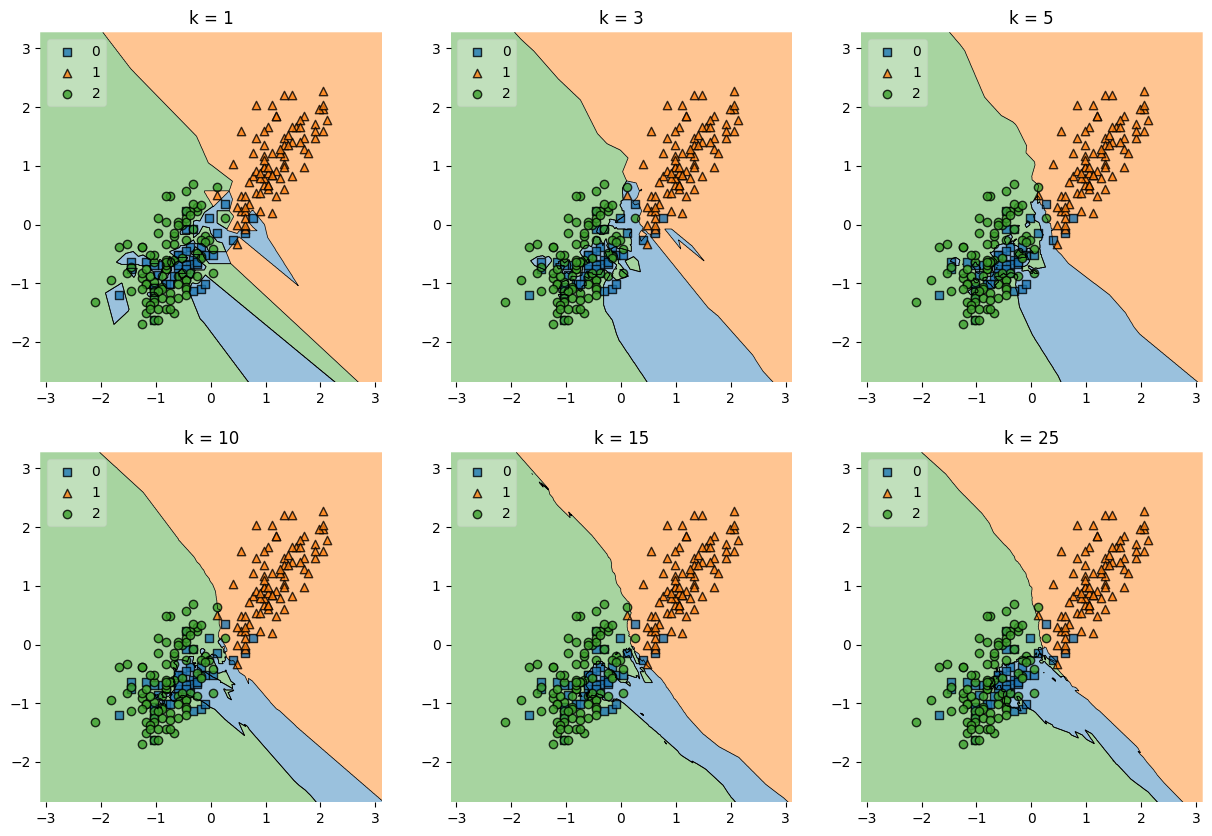

In [99]:
# В примере пингвинчики закодированы в алфавитном порядке, ваш вариант будет отличаться.
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools


gs = gridspec.GridSpec(2, 3)

rows = [0, 1]
cols = [0, 1, 2]

fig = plt.figure(figsize=(15,10))
y_tr_np = y_train.values.astype(int)

for (row, col), clf, k in zip(itertools.product(rows, cols), clfs, lst):
    
    ax = plt.subplot(gs[row, col])
    plot_decision_regions(X_tr_sc, y_tr_np, clf=clf, legend=2, ax=ax)
    ax.set_title(f'k = {k}')


plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Итак, для начала, результат при **k=1** показывает явные симптомы переобучения. Это видно по тому, что результат на обучающей выборке близок к 1, а на тестовой - наихудший из представленных. Это логично, потому что модель определяет принадлежность элемента к какой-то группе по 1 блиайшему соседу - то есть по самому себе.. Поэтому на тренировочной выборке - модель работает почти идеально.  

Наилучший результат по тестовой выборке даёт **k=25**, что говорит о высокой обобщающей способности модели. 

По самим рисункам можно видеть: чем больше **k**(до 25 включительно) тем более плавная структура, нет разорванных значений и "островков" внутри площадей группы 

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

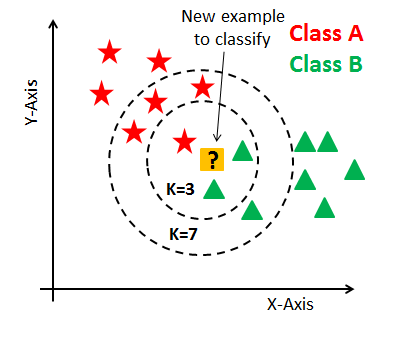

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [100]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def count_distance(self, x, y):
        return np.linalg.norm(self.X - self.y, axis=1)
        

    def predict(self, X):

        preds = []

        for x in X:
            dist = np.linalg.norm(self.X_train - x, axis=1)
            
            k_n = min(self.k, len(self.X_train)) #K не может быть больше, чем выборка
            k_marks = np.argsort(dist)[:k_n] # расстояния по порядку до K ближайшего
            K_ans = self.y_train[k_marks] #сохраняем ответы по индексам от argsort
            
            most_frq = Counter(K_ans).most_common(1)[0][0]
            
            preds.append(most_frq)

        return np.array(preds)


In [101]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [102]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [103]:
lst = [1, 3, 5, 10, 15, 25] # тут не знал, сколько нужно брать, можно было сделать и цикл по всем возможным К
best_acc = 0
best_k = ''

for k in lst:
    knn = KNN(k)
    knn.fit(X_tr_sc, y_train)
    y_pred = knn.predict(X_te_sc)
    acc_score = accuracy_score(y_test, y_pred)
    if acc_score > best_acc:
        best_k = k
        best_acc = acc_score
print(f'Лучшее k: {best_k} с точностью {round(best_acc, 2)} на test')

Лучшее k: 25 с точностью 0.84 на test


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [104]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [105]:
data.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Итак, пропущенных значений **нет**. Однако непонятно, зачем нужен столбец **Unnamed: 0**. По сути он дублирует индексы питона, только начинается с единицы  
Поэтому удалим его

In [106]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [107]:
data.head() #Избавились от ненужного столбца

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [108]:
#Целиком корреляционная матрица
data.corr(numeric_only=True)

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


In [109]:
data.corr(numeric_only=True)['price'].sort_values(key=abs)#отсортируем по модулю, чтоб выбрать наибольшие корр. по модулю

depth   -0.010647
table    0.127134
z        0.861249
y        0.865421
x        0.884435
carat    0.921591
price    1.000000
Name: price, dtype: float64

В целом наибольшую корреляцию имеют признаки: **carat, x, y, z**

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [110]:
data.dtypes #Итого нам надо закодировать cut, color, clarity

carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [111]:
cols = ['cut', 'color', 'clarity']
df_clean = pd.get_dummies(data, columns=cols, drop_first=True, dtype='int')

In [112]:
df_clean

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,1,...,0,1,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,1,0,0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,0,1,0,...,0,0,0,0,1,0,0,0,0,0
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,1,0,0,...,0,0,0,0,1,0,0,0,0,0
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,0,0,0,...,0,0,0,0,1,0,0,0,0,0
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,0,0,1,...,1,0,0,0,0,1,0,0,0,0


In [113]:
df_clean.dtypes #закодировали

carat            float64
depth            float64
table            float64
price              int64
x                float64
y                float64
z                float64
cut_Good           int64
cut_Ideal          int64
cut_Premium        int64
cut_Very Good      int64
color_E            int64
color_F            int64
color_G            int64
color_H            int64
color_I            int64
color_J            int64
clarity_IF         int64
clarity_SI1        int64
clarity_SI2        int64
clarity_VS1        int64
clarity_VS2        int64
clarity_VVS1       int64
clarity_VVS2       int64
dtype: object

**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [114]:
from sklearn.model_selection import train_test_split


X = df_clean.drop('price', axis=1)
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [115]:
sc = StandardScaler()
nums = ['carat', 'depth', 'table', 'x', 'y', 'z']
X_tr_sc = X_train.copy()
X_te_sc = X_test.copy() # на всякий пожарный сделаем через копии

X_tr_sc[nums] = sc.fit_transform(X_train[nums])
X_te_sc[nums] = sc.fit_transform(X_test[nums])


In [116]:
X_tr_sc # значения стандартизированы, т.е. std = 1, a mean = 0

,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
19497,0.862659,-0.311437,-0.207099,1.055581,0.986556,0.968253,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
31229,-1.029889,0.178549,-0.656213,-1.207734,-1.202544,-1.168276,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
22311,0.862659,0.458541,-0.207099,0.904099,0.951670,0.982309,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
278,0.021527,0.598537,-1.105327,0.164512,0.192898,0.251391,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
6646,-0.020530,-0.031445,-0.656213,0.182333,0.184176,0.181110,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.526206,0.458541,0.691128,0.663511,0.672581,0.715243,0,0,0,1,...,0,1,0,0,0,0,0,1,0,0
44732,-0.693436,-0.521432,-1.105327,-0.628540,-0.635646,-0.676312,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
38158,-0.987832,-1.011418,0.242014,-1.109717,-1.115329,-1.182333,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
860,0.210782,0.738533,0.691128,0.351636,0.253949,0.391952,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0


После стандартизации коэффициенты интерпретируется иначе:   
*Насколько увеличится целевая переменная, если **признак** увеличится на 1 стандартное отклонение.* 

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [117]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


lr = LinearRegression()
model = lr.fit(X_tr_sc, y_train)
y_tr_pred = lr.predict(X_tr_sc)
y_te_pred = lr.predict(X_te_sc)

print(f'MSE на тренировочной выборке {mean_squared_error(y_train, y_tr_pred)}')
print(f'MSE на тестовой выборке {mean_squared_error(y_test, y_te_pred)}')

MSE на тренировочной выборке 1290541.9147450614
MSE на тестовой выборке 1250342.953794689


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [118]:
coef_df = pd.DataFrame({'predictor': X_tr_sc.columns, 'coefficient': model.coef_})
sort_coef_df = coef_df.sort_values('coefficient', key=abs)
sort_coef_df

,predictor,coefficient
4,y,-6.458917
5,z,-34.258945
2,table,-60.332280
1,depth,-90.173817
10,color_E,-217.028968
11,color_F,-273.303976
12,color_G,-500.160238
6,cut_Good,595.521080
9,cut_Very Good,743.301360
8,cut_Premium,777.769963


По модулю оценка коэффициентов среди вещественных переменных самая большая у признаков **carat** и **x**

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [119]:
from sklearn.linear_model import Lasso, Ridge


lasso = Lasso(10).fit(X_tr_sc, y_train)
ridge = Ridge(10).fit(X_tr_sc, y_train)

#Посмотрим на коэффициенты при вещественных признаках (Lasso)
coef_df = pd.DataFrame({'predictor': X_tr_sc.columns, 'coefficient': lasso.coef_})
sort_coef_df = coef_df.sort_values('coefficient', key=abs)
sort_coef_df

,predictor,coefficient
6,cut_Good,-0.000000
4,y,-0.000000
10,color_E,0.000000
11,color_F,-0.000000
17,clarity_SI1,3.515381
5,z,-6.279439
8,cut_Premium,76.636591
9,cut_Very Good,90.907316
2,table,-109.868576
12,color_G,-129.223962


In [120]:
#То же самое, но Ridge
coef_df = pd.DataFrame({'predictor': X_tr_sc.columns, 'coefficient': ridge.coef_})
sort_coef_df = coef_df.sort_values('coefficient', key=abs)
sort_coef_df

,predictor,coefficient
4,y,-5.916126
5,z,-33.689994
2,table,-63.430106
1,depth,-93.746314
10,color_E,-205.012057
11,color_F,-260.098597
12,color_G,-481.915657
6,cut_Good,618.971148
9,cut_Very Good,773.390190
8,cut_Premium,801.950615


Можно было бы посмотреть по всем коэффициентам, но там мантисса мешает пониманию изменений  
Можно сказать, что проблема мультиколлинеарности действительно существовала. Причём **Lasso** сильнее "штрафовал" модель. К примеру, коэффициент при **y** вовсе стал близок к 0, когда у **Ridge** он равен **-9.05**

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

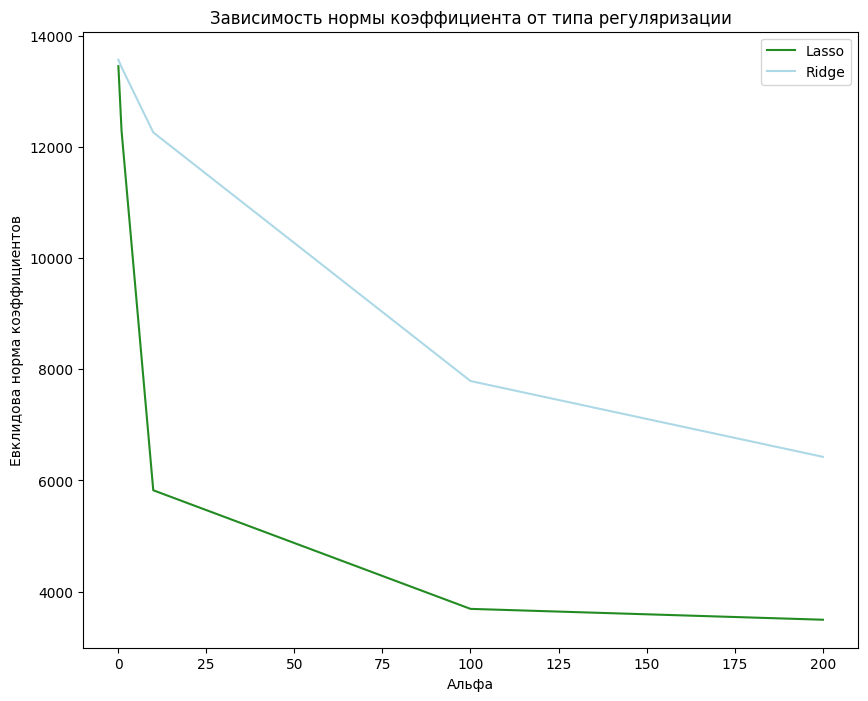

In [121]:
alphs = [0.1, 1, 10, 100, 200]
lasso_lst = []
ridge_lst = []

for a in alphs:
    lasso = Lasso(a).fit(X_tr_sc, y_train)
    l_norm = np.linalg.norm(lasso.coef_)
    lasso_lst.append(l_norm)

    ridge = Ridge(a).fit(X_tr_sc, y_train)
    r_norm = np.linalg.norm(ridge.coef_)
    ridge_lst.append(r_norm)

plt.figure(figsize=(10, 8))
plt.plot(alphs, lasso_lst, color='forestgreen', label='Lasso')
plt.plot(alphs, ridge_lst, color='lightblue', label='Ridge')
plt.xlabel('Альфа')
plt.ylabel('Евклидова норма коэффициентов')
plt.title('Зависимость нормы коэффициента от типа регуляризации')
plt.legend()
plt.show()

Сильнее норму коэффициентов снижает конечно же **Lasso**. И используют для отбора Lasso, потому что он часто зануляет маленькие коэффициенты за счёт того, что он пропорционален абсолютной величине коэффициента(у **Ridge** квадрат) 

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [122]:
from sklearn.linear_model import LassoCV


alphs = [0.1, 1, 10, 100, 200]
lc = LassoCV(alphas=alphs, cv=5)
lc.fit(X_tr_sc, y_train)

matrix = lc.mse_path_
avg = np.mean(matrix, axis=1)
a = lc.alphas_
idx = np.argmin(avg) #наибольшее качество у того значения, при котором ошибка минимальная

print(f'Лучшее значение альфа: {a[idx]}')

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.372e+08, tolerance: 4.848e+07
  model = cd_fast.enet_coordinate_descent_gram(


Лучшее значение альфа: 0.1


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [123]:
ls = Lasso(0.1).fit(X_tr_sc, y_train)
coef_df = pd.DataFrame({'predictor': X_tr_sc.columns, 'coefficient': ls.coef_})
sort_coef_df = coef_df.sort_values('coefficient', key=abs)
sort_coef_df

,predictor,coefficient
4,y,-5.607738
5,z,-33.944427
2,table,-60.981853
1,depth,-91.073033
10,color_E,-211.661902
11,color_F,-267.942750
12,color_G,-494.291991
6,cut_Good,585.179038
9,cut_Very Good,733.735978
8,cut_Premium,767.655001


Итак, наибольшие коэффициенты из вещственных имеет **carat**, что логично, ведь это самая базовая характеристика качества бриллианты(по крайней мере для обывателя вроде меня). Дальше большую роль играют различные показатели чистоты, тоже разумно. Помимо этого, это бинарные признаки, после применения к ним **get_dummies**, а значит при наличии определённого качества добавляется 1, при отсутствие - ничего не добавляется. Из вещественных ещё немалую роль играет параметр **x**(длина бриллианта). В целом логично, что при этом **y** и **z** несут меньший вклад. По сути бриллиант не бывает формы трубы (типо большая длина, но малая ширина и высота). Поэтому увеличение одного из этих признаков почти автоматически увеличивает другие. Аналогично и с **carat**. Карат - это вес. Логично, что он в том числе связан с длиной, шириной и высотой. Между ними, собственно говоря, и высокая корреляция => они связаны.  

Предыдущая мысль наводит нас на идею о наиболее неинформативных признаках. **Lasso** удалил мультиколлинеарность, поэтому хоть и корреляция между **y, z и price** высокая, их вклад довольно низкий относительно других признаков, достаточно фактора увеличения **x**. Осавшиеся вещественные просто изначально были с низкой корреляцией, отсюда и маленький вес :)


**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [124]:
y_pred_l = ls.predict(X_te_sc)
print(f'MSE Lasso-регрессии: {round(mean_squared_error(y_test, y_pred_l), 2)}')

MSE Lasso-регрессии: 1249904.77


**1249904.77(MSE Lasso-регрессии) < 1250342.95(MSE обычной Линейной регрессии) => Lasso-регрессия оказалась лучше для предсказаний**, потому что убрала фактор мультиколлинеарности. В нашем изначальном датасете была изначаль очень высокая корреляция по 4-ём признакам, хотя фактически, и это был 1-2 очень похожих признака. 